# Torsion Analysis of Circular Shafts
### Mechanics of Solids Project



## Why are we doing this?

Torsion is one of the most common load types in mechanical engineering, eg-car drive shaft, a drill bit, or a door handle. When a shaft is twisted, it develops shear stresses inside. The goal of this project is to:

1. **Understand** how the internal torque varies along the shaft depending on how it is supported (fixed-free vs fixed-fixed)
2. **See** how that shear stress distributes across the cross section (solid vs hollow circular beam)
3. **Draw** Mohr's circle to find the principal stresses and use it to calculate stress on a rotated element

All derivations follow Crandall & Dahl Mechanics of Solids Chapter 6.

## Imports and Problem Setup

**What this cell does:** Loads numpy and matplotlib, then defines all the geometry, material, and loading values.

**How to change values:** Edit the numbers below.
- To change shaft size - edit R_solid, R_out, R_in, L
- To change loading - edit T1, T2, at points - z1, z2
- To change the analysis point - edit pt_idx (0 to 499, maps to z=0 to z=L)
- To rotate the stress element - edit angle (degrees)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# geometry (mm)
L= 1000.0 # shaft length
R_solid= 30.0 # solid shaft outer radius
R_out= 30.0 # hollow shaft outer radius (same for comparison)
R_in= 0.65 * R_out # hollow inner radius  (k = 0.65)
k=R_in/ R_out

# Torsional loading
T1= 800000 # torque 1 in N.mm  (800 N.m)
z1= 350 # position of T1 along shaft
T2= 400000 # torque 2 in N.mm
z2= 750# position of T2

# where along the shaft do we want to analyse stress?
# index goes from 0 to 499, covering z = 0 to z = L
pt_idx= 150                                                                                                 #Change this to move the analysis point
theta_input=30                                                                                      #Change this to rotate the stress element

## Polar Moment of Area

**What this cell does:** Computes the polar moment of area $I_z$ and cross-sectional area $A$ for both the solid and hollow shaft.

A larger $I_z$ means the shaft resists twisting better.

In [ ]:
# polar moment of area  I_z=(pi/2)(R_out^4 - R_in^4)
# for solid shaft set R_in = 0

Iz_solid=(np.pi/2)*R_solid**4
Iz_hollow=(np.pi/2) * (R_out**4-R_in**4)

A_solid=np.pi*R_solid**2 # Simply the area of circular sections
A_hollow=np.pi *(R_out**2 -R_in**2)

##Wall Reactions and Internal Torque Diagram

**What this cell does:** Finds the reaction torques at the walls, then builds the internal torque M_t(z) at every point along the shaft.

**Fixed-Free (cantilever):** Only one wall. It must resist all applied torques.  

**Fixed-Fixed:** Two walls share the load. We use the compatibility condition the shaft cannot rotate at either wall, so the total angle of twist must be zero.  

In [ ]:

#Create 500 evaluation points along the length of the shaft
z_arr =np.linspace(0, L, 500)
q=z_arr[pt_idx]  # point of analysis

Mt_ff=[]
Mt_fix=[]

for z in z_arr:
    current_twist = T1 + T2 # start with all of it
    if z > z1:
        current_twist=current_twist-T1 # lose some after the first mark
    if z > z2:
        current_twist=current_twist-T2 # lose the rest at the end

    Mt_ff.append(current_twist/1000)

for z in z_arr:
    current_twist = (T1*(L-z1)+T2*(L-z2)) / L
    if z > z1:
        current_twist=current_twist-T1
    if z > z2:
        current_twist=current_twist-T2

    Mt_fix.append(current_twist/1000)


## Plot: Internal Torque Diagrams



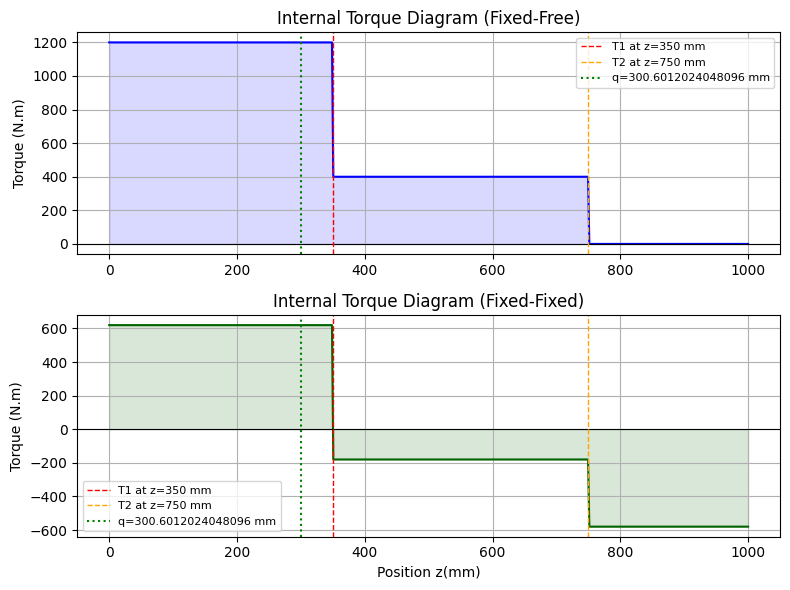

In [ ]:
#this code was directly copied from Matplotlib documentation and changed according to our values...
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Plot Fixed-Free
ax1.plot(z_arr, Mt_ff, color='blue')
ax1.fill_between(z_arr, Mt_ff, 0, alpha=0.15, color='blue')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(z1, color='red', linestyle='--', linewidth=1, label=f'T1 at z={z1} mm')
ax1.axvline(z2, color='orange', linestyle='--', linewidth=1, label=f'T2 at z={z2} mm')
ax1.axvline(q, color='green', linestyle=':', linewidth=1.5, label=f'q={q} mm')
ax1.set_title('Internal Torque Diagram (Fixed-Free)')
ax1.set_ylabel('Torque (N.m)')
ax1.grid(True)
ax1.legend(fontsize=8)

# Plot Fixed-Fixed
ax2.plot(z_arr, Mt_fix, color='darkgreen')
ax2.fill_between(z_arr, Mt_fix, 0, alpha=0.15, color='darkgreen')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(z1, color='red', linestyle='--', linewidth=1, label=f'T1 at z={z1} mm')
ax2.axvline(z2, color='orange', linestyle='--', linewidth=1, label=f'T2 at z={z2} mm')
ax2.axvline(q, color='green', linestyle=':', linewidth=1.5, label=f'q={q} mm')
ax2.set_title('Internal Torque Diagram (Fixed-Fixed)')
ax2.set_ylabel('Torque (N.m)')
ax2.set_xlabel('Position z(mm)')
ax2.grid(True)
ax2.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('torque_BMD.png')
plt.show()

## Shear Stress Distribution Alongs the Radius

**What the graph shows:**  
How shear stress varies from the centre of the shaft to the outer edge, for the fixed-fixed and fixed-free case at the pt_idx.


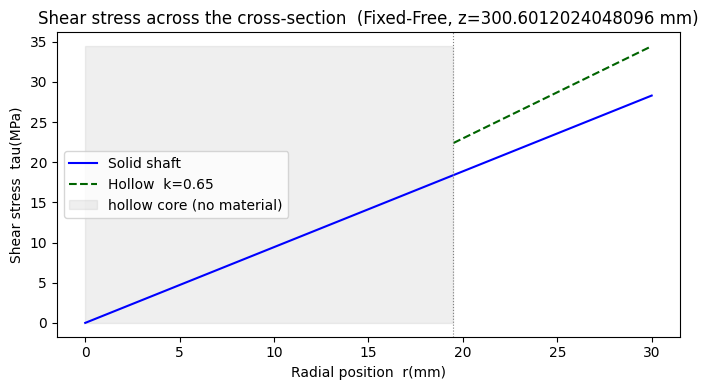

Max shear stress solid(FF)= 28.294212105225842 MPa
Max shear stress hollow (FF)= 34.442394851118266 MPa


In [ ]:
# stress varies linearly from 0 at centre to tau_max at outer surface
# for hollow, it is still linear but starts at R_in not at 0

r_s=np.linspace(0,R_solid, 300)
r_h=np.linspace(R_in,R_out,300)

Mt_q_ff=Mt_ff[pt_idx]   #Moment at the point q                                                !!ENTER LOCATION OF TORSIONAL ANALYSIS & TYPE OF SUPPORT!!
Mt_q_fix=Mt_fix[pt_idx]

# Fixed free beam
tau_s= Mt_q_ff*1000*r_s/Iz_solid
tau_h= Mt_q_ff*1000*r_h/Iz_hollow

#Max values
tau_s_Max = Mt_q_ff*1000* R_solid/Iz_solid
tau_h_Max =Mt_q_ff*1000*R_out/Iz_hollow

#Ploted using Matplotlib Documentation text
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(r_s, tau_s, color='blue', label='Solid shaft')
ax.plot(r_h, tau_h, color='darkgreen', label=f'Hollow  k={k}', linestyle='--')

# shade the hollow core (no material there)
ax.fill_betweenx([0, tau_h[-1]], 0, R_in, color='grey', alpha=0.12, label='hollow core (no material)')

ax.axvline(R_in, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Radial position  r(mm)')
ax.set_ylabel('Shear stress  tau(MPa)')
ax.set_title(f'Shear stress across the cross-section  (Fixed-Free, z={q} mm)')
ax.legend()

plt.tight_layout()
#plt.savefig('stress_dist.png')
plt.show()

print(f'Max shear stress solid(FF)= {tau_s_Max} MPa')
print(f'Max shear stress hollow (FF)= {tau_h_Max} MPa')

#Mohr's Circle for Both Support Types

**What the graph shows:**  
Four Mohr's circles in total, solid and hollow for each support condition.

In pure torsion the stress state at any surface point is:
sigma_z = 0,sigma_x = 0, tau_angle = tau_max

This means the Mohr circle is **centred at the origin** with radius =tau.

- The **red dots** (faces at 0, pi/2 angles) are your original stress state: pure shear, no normal stress.
- The **orange triangle** is the rotated element at input angle. As you rotate the element, normal stresses appear and shear stress changes.
- The **principal stresses** sigma_1 = tau, sigma_2 =tau are where the circle crosses the horizontal axis.


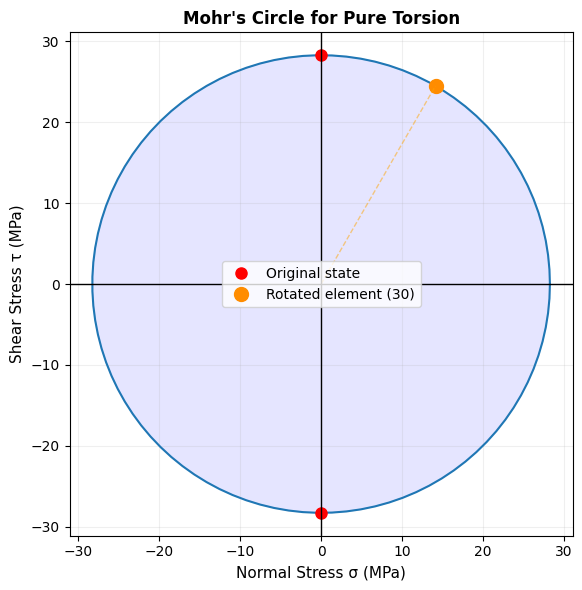

In [ ]:
tau = tau_s_Max  # Change value here

# Mohr's Circle for Pure Torsion
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Draw the circle (radius = tau)
angles = np.linspace(0, 2*np.pi, 100)
x = tau * np.cos(angles)
y = tau * np.sin(angles)
ax.plot(x, y)
ax.fill(x, y, alpha=0.1, color='blue')

# Red dots are original stress stat
# Pure sHear: sigma = 0, tau_max = tau
ax.plot([0, 0], [tau, -tau], 'ro', markersize=8, label='Original state')

# Orange point: rotated element state
# Important: element rotated by θ appears at angle 2θ on Mohr circle
mohr_angle = 2 * np.radians(theta_input)
sigma_n_rotated = tau*np.sin(mohr_angle) # normal stress
tau_rotated = tau*np.cos(mohr_angle)  # shear stress
ax.plot(tau * np.cos(mohr_angle), tau * np.sin(mohr_angle),
        'o', color='darkorange', markersize=10,
        label=f'Rotated element ({theta_input})')

# Draw line from origin to show rotation angle on circle
ax.plot([0, tau * np.cos(mohr_angle)], [0, tau * np.sin(mohr_angle)],
        'orange', linewidth=1, linestyle='--', alpha=0.5)

# Axes and labels
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Normal Stress σ (MPa)', fontsize=11)
ax.set_ylabel('Shear Stress τ (MPa)', fontsize=11)
ax.set_title("Mohr's Circle for Pure Torsion", fontsize=12, weight='bold')
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Stress Element at a Chosen Orientation

**What the graph shows:**  
A small square element cut from the shaft surface, rotated by theta_input degrees. The red arrows are normal stresses and the orange arrows are shear stresses acting on each face.

- At **theta = 0**: the element faces align with the shaft axis  (pure shear, no normal stress.)
- At **theta = 45**: the element is aligned with the principal planes ( maximum tension and compression +Tau, -Tau, zero shear.)


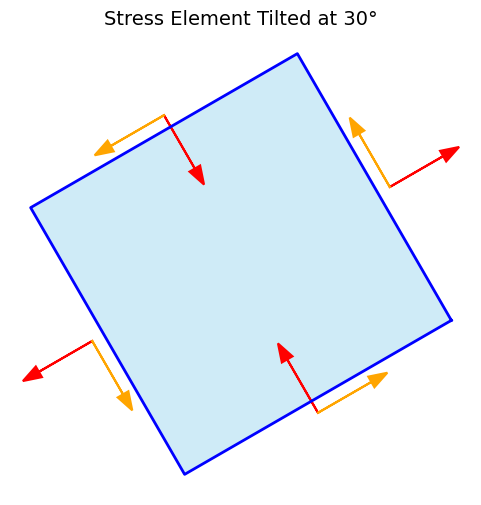

Angle = 30°
1. MAX SHEAR (tau_max): 28.294212105225842 MPa
2. NORMAL STRESS (sigma_z): 24.50 MPa
3. COMPLEMENTARY NORMAL (sigma_x): -24.50 MPa
4. NEW SHEAR (tau_rotated): 14.15 MPa


In [ ]:
th = np.radians(theta_input)

# When we rotate an element in pure torsion, the shear turns into normal stress
sigma_z = tau * np.sin(2 * th)
sigma_x = -tau * np.sin(2 * th)
tau_new = tau * np.cos(2 * th)

# Plot (This code was taken from Geeks for Geeks forum for plotting an equal element)
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5) # Size
ax.set_aspect('equal')
ax.axis('off')

# Corner points for a rotated 1x1 square
# We use sin and cos to make sure the box tilts with theta
c = np.cos(th)
s = np.sin(th)
box = np.array([
    [ c + s,  s - c], # Top-Right
    [ c - s,  s + c], # Top-Left
    [-c - s, -s + c], # Bottom-Left
    [-c + s, -s - c], # Bottom-Right
    [ c + s,  s - c]  # Back to start
])

ax.fill(box[:,0], box[:,1], color='skyblue', alpha=0.4)
ax.plot(box[:,0], box[:,1], color='blue', linewidth=2)

# Red arrows = Normal stress (Sigma)
# Orange arrows = Shear stress (Tau)
def draw_arrow(x, y, dx, dy, col):
    # Only draw if there is actual stress (prevents tiny dot artifacts when stress is 0)
    if abs(dx) > 0.01 or abs(dy) > 0.01:
        ax.arrow(x, y, dx*0.4, dy*0.4, head_width=0.08, color=col, linewidth=1.5)

# Add arrows to the right face
right_face  = np.array([ c+0.1,  s])
left_face   = np.array([-c-0.1, -s])
top_face    = np.array([-s,  c+0.1])
bottom_face = np.array([ s, -c-0.1])

# sigma_z acts on vertical faces
draw_arrow(*right_face,  c*np.sign(sigma_z),  s*np.sign(sigma_z), 'red')
draw_arrow(*left_face,  -c*np.sign(sigma_z), -s*np.sign(sigma_z), 'red')

# sigma_x acts on horizontal faces
draw_arrow(*top_face,   -s*np.sign(sigma_x),  c*np.sign(sigma_x), 'red')
draw_arrow(*bottom_face, s*np.sign(sigma_x), -c*np.sign(sigma_x), 'red')

# Maintain consistent rotational direction
# Right face
draw_arrow(*right_face,  -s*np.sign(tau_new),  c*np.sign(tau_new), 'orange')
# Left face
draw_arrow(*left_face,    s*np.sign(tau_new), -c*np.sign(tau_new), 'orange')
# Top face
draw_arrow(*top_face,    -c*np.sign(tau_new), -s*np.sign(tau_new), 'orange')
# Bottom face
draw_arrow(*bottom_face,  c*np.sign(tau_new),  s*np.sign(tau_new), 'orange')

plt.title(f"Stress Element Tilted at {theta_input}°", fontsize=14)
plt.show()

# Print the results
print(f"Angle = {theta_input}°")
print(f"1. MAX SHEAR (tau_max): {tau} MPa")
print(f"2. NORMAL STRESS (sigma_z): {sigma_z:.2f} MPa")
print(f"3. COMPLEMENTARY NORMAL (sigma_x): {sigma_x:.2f} MPa")
print(f"4. NEW SHEAR (tau_rotated): {tau_new:.2f} MPa")